Import required packages

In [272]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta



Read consolidated, cleaned, and pre-processed data stored in `..\data` directory

In [273]:
birdsong_df = pd.read_csv("..\\output\\birdsong_df.csv")

### Snapshot of raw data

In [274]:
birdsong_df
birdsong_df.info()
birdsong_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348377 entries, 0 to 348376
Data columns (total 14 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   common_name                         348377 non-null  object 
 1   date                                348377 non-null  object 
 2   bird_count                          348377 non-null  float64
 3   county                              348377 non-null  object 
 4   family                              348377 non-null  object 
 5   total_monthly_precipitation         348377 non-null  float64
 6   monthly_max_temp                    348377 non-null  float64
 7   monthly_min_temp                    348377 non-null  float64
 8   urban_population_level              348377 non-null  int64  
 9   county_total_population             348377 non-null  float64
 10  is_fire                             348377 non-null  int64  
 11  is_flood                  

,common_name,date,bird_count,county,family,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood,bird_count_adjusted_for_population,season
0,Cackling Goose,2021-01,30.0,Arapahoe,"Ducks, Geese, and Waterfowl",6.388095,7.923333,-5.823333,5,660310.560,0,0,0.000045,Winter
1,Canada Goose,2021-01,100.0,Arapahoe,"Ducks, Geese, and Waterfowl",6.388095,7.923333,-5.823333,5,660310.560,0,0,0.000151,Winter
2,Great Horned Owl,2021-01,1.0,Arapahoe,Owls,6.388095,7.923333,-5.823333,5,660310.560,0,0,0.000002,Winter
3,Eastern Screech-Owl,2021-01,2.0,Larimer,Owls,10.825893,1.854118,-10.457222,5,361938.528,0,0,0.000006,Winter
4,Northern Saw-whet Owl,2021-01,1.0,Larimer,Owls,10.825893,1.854118,-10.457222,5,361938.528,0,0,0.000003,Winter


## Additional Data Transformations to Support Visualizations 

Grouped by County Monthly Aggregation (sorted descending by adjusted bird count)

In [275]:
# aggregate data by county, and date to get total bird count, county total population and average min and max temperatures per county, per month
birdsong_df_county_month = birdsong_df.groupby(['county', 'date']).agg({'bird_count': 'sum','county_total_population': 'mean', 'monthly_min_temp': 'mean', 'monthly_max_temp': 'mean', 'total_monthly_precipitation': 'mean', 'bird_count_adjusted_for_population': 'sum','is_fire': 'mean', 'is_flood': 'mean','urban_population_level': 'mean'}).reset_index()
print(birdsong_df_county_month.head())

  county     date  bird_count  county_total_population  monthly_min_temp  \
0  Adams  2021-01      1092.0               523728.576         -6.441190   
1  Adams  2021-02       244.0               523728.576         -9.320278   
2  Adams  2021-03        53.0               523728.576         -3.354056   
3  Adams  2021-04        21.0               523728.576         -0.706306   
4  Adams  2021-05        91.0               523728.576          5.737639   

   monthly_max_temp  total_monthly_precipitation  \
0          8.038611                         1.50   
1          5.077778                         5.40   
2         11.264028                        45.70   
3         14.906611                        28.85   
4         19.938750                        68.40   

   bird_count_adjusted_for_population  is_fire  is_flood  \
0                            0.002085      0.0       0.0   
1                            0.000466      0.0       0.0   
2                            0.000101      0.0    

Grouped by County Annually (sorted descending by year and adjusted bird count)


In [276]:
# save date as year in new column called year
birdsong_df['year'] = pd.to_datetime(birdsong_df['date']).dt.to_period('Y')
# aggregate data by county, and year to get total bird count, county total population and average min and max temperatures per county, per month-year combination
birdsong_df_county_year= birdsong_df.groupby(['county', 'year']).agg({'bird_count': 'sum','county_total_population': 'mean', 'monthly_min_temp': 'mean', 'monthly_max_temp': 'mean', 'bird_count_adjusted_for_population': 'sum', 'is_fire': 'mean', 'is_flood': 'mean'}).reset_index()
# sort the dataframe by year and adjusted bird count in descending order to ensure the bars are in the correct order
birdsong_df_county_year_sorted = birdsong_df_county_year.sort_values(by=['year', 'bird_count_adjusted_for_population'], ascending=False)
birdsong_df_county_year_sorted.head(20)

,county,year,bird_count,county_total_population,monthly_min_temp,monthly_max_temp,bird_count_adjusted_for_population,is_fire,is_flood
164,Kit Carson,2025,53845.0,7375.052111,3.288446,19.693192,7.300965,0.0,0.0
149,Jackson,2025,4480.0,1435.049649,3.138280,18.608672,3.121843,0.0,0.0
49,Cheyenne,2025,4146.0,1819.047706,6.002433,23.801485,2.279215,0.0,0.0
189,Lincoln,2025,9771.0,5905.661172,3.556046,20.332307,1.654514,0.0,0.0
29,Bent,2025,5720.0,5879.645044,6.660305,24.790407,0.972848,0.0,0.0
59,Conejos,2025,7110.0,7764.253393,-3.796379,13.073621,0.915735,0.0,0.0
269,Rio Grande,2025,8828.0,12008.004276,-2.374362,14.348918,0.735176,0.0,0.0
159,Kiowa,2025,1093.0,1504.772873,5.196965,22.049798,0.726355,0.0,0.0
224,Morgan,2025,14511.0,30294.220685,6.731148,25.471694,0.479002,0.0,0.0
234,Ouray,2025,2330.0,5072.104415,5.072526,22.965990,0.459375,0.0,0.0


Grouped by County All Years (sorted descending by adjusted bird count)

In [277]:
# aggregate data by county to get total bird count, county total population and average min  and max temperatures per county
birdsong_df_county = birdsong_df.groupby(['county']).agg({'bird_count': 'sum',
'county_total_population': 'mean', 'monthly_min_temp': 'min', 'monthly_max_temp': 'max', 'total_monthly_precipitation': 'mean', 'urban_population_level': 'mean','bird_count_adjusted_for_population': 'sum', 'is_fire': 'mean', 'is_flood': 'mean'}).reset_index()
print(birdsong_df_county.head(20))
# sort the dataframe by count_per_capita in descending order to ensure the bars are in the correct order
birdsong_df_county_sorted = birdsong_df_county.sort_values(by='bird_count_adjusted_for_population', ascending=False)
print(birdsong_df_county_sorted.head(20))

         county  bird_count  county_total_population  monthly_min_temp  \
0         Adams     22239.0            531307.213593        -11.910694   
1       Alamosa      8647.0             16752.071325        -16.210000   
2      Arapahoe    247730.0            671334.122465        -10.313333   
3     Archuleta      4695.0             13669.832696        -13.655000   
4          Baca     12999.0              3592.061039        -10.830000   
5          Bent     62753.0              5780.753791        -12.290000   
6       Boulder    241828.0            338470.882931        -12.433333   
7    Broomfield     39592.0             76195.229302        -12.350000   
8       Chaffee     23225.0             19949.972581        -15.246667   
9      Cheyenne      5141.0              1800.374809        -12.746667   
10  Clear Creek      7685.0              9600.656432        -16.188000   
11      Conejos     24458.0              7640.993829        -15.337500   
12     Costilla      8901.0           

Grouped by Family Monthly

In [278]:
# save date as year in new column called year
birdsong_df['month-year'] = pd.to_datetime(birdsong_df['date']).dt.to_period('M')
# aggregate data by family, and year to get total bird count, family total population and average min and max temperatures per family, per month-year combination
birdsong_df_family_month = birdsong_df.groupby(['family', 'month-year']).agg({'bird_count': 'sum',
'county_total_population': 'mean', 'monthly_min_temp': 'mean', 'monthly_max_temp': 'mean', 'total_monthly_precipitation': 
'mean', 'bird_count_adjusted_for_population': 'sum','is_fire': 'mean', 'is_flood': 'mean','urban_population_level': 
'mean'}).reset_index()
# sort the dataframe by year and adjusted bird count in descending order to ensure the bars are in the correct order
birdsong_df_family_month_sorted = birdsong_df_family_month.sort_values(by=['month-year', 
'bird_count_adjusted_for_population'], ascending=False)
birdsong_df_family_month_sorted.head(20)
birdsong_df_family_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3178 entries, 0 to 3177
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype    
---  ------                              --------------  -----    
 0   family                              3178 non-null   object   
 1   month-year                          3178 non-null   period[M]
 2   bird_count                          3178 non-null   float64  
 3   county_total_population             3178 non-null   float64  
 4   monthly_min_temp                    3178 non-null   float64  
 5   monthly_max_temp                    3178 non-null   float64  
 6   total_monthly_precipitation         3178 non-null   float64  
 7   bird_count_adjusted_for_population  3178 non-null   float64  
 8   is_fire                             3178 non-null   float64  
 9   is_flood                            3178 non-null   float64  
 10  urban_population_level              3178 non-null   float64  
dtypes: float64(9), ob

## Visualizations

#### County Min and Max Temp vs Adjusted Bird Counts



C:\Users\melis\AppData\Local\Temp\ipykernel_39048\3411284263.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)


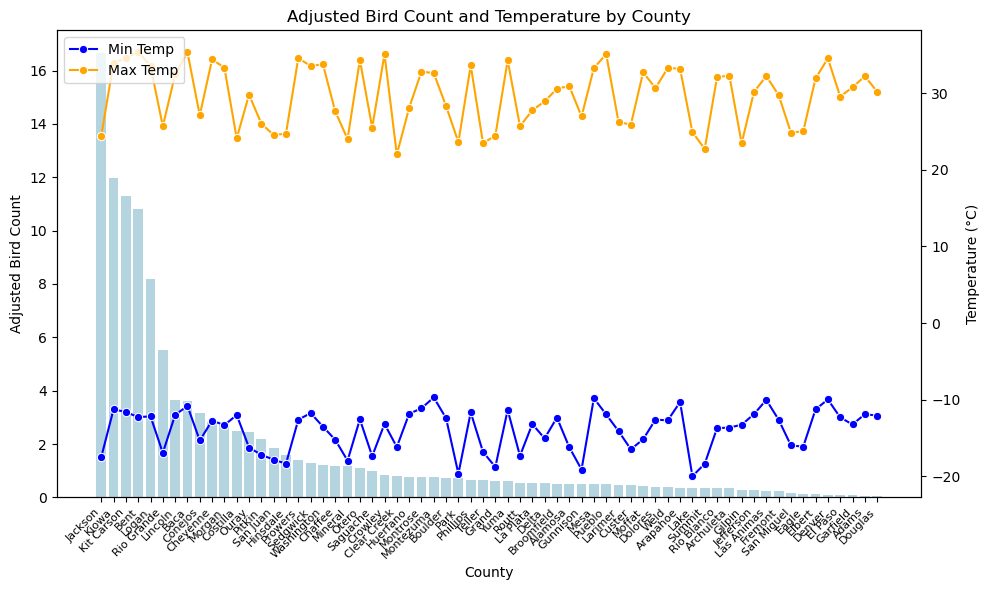

In [304]:
# Create line graph with 2 lines, one for min temp  per county and one with max temp per county overlay ontop of bar graph of bird counts per capita per county in descending count order. Use different colors for each line and bar graph. Add labels for x and y axes, title, and legend to differentiate between the lines and bars. 

# Create figure and axis objects
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plot bar graph of bird counts per capita per county in descending order by count
sns.barplot(x='county', y='bird_count_adjusted_for_population', data=birdsong_df_county.sort_values(by='bird_count_adjusted_for_population', ascending=False), ax=ax1, color='lightblue', errorbar=None)
ax1.set_xlabel('County')


ax1.set_ylabel('Adjusted Bird Count')
ax1.tick_params(axis='y')
# Create second y-axis for temperature
ax2 = ax1.twinx()
# Plot line graph of min and max temperatures per county
sns.lineplot(x='county', y='monthly_min_temp', data=birdsong_df_county, ax=ax2, color='blue', marker='o', label='Min Temp')
sns.lineplot(x='county', y='monthly_max_temp', data=birdsong_df_county, ax=ax2, color='orange', marker='o', label='Max Temp')
ax2.set_ylabel('Temperature (°C)')     
ax2.tick_params(axis='y')
# Add title and legend
plt.title('Adjusted Bird Count and Temperature by County')
ax2.legend(loc='upper left')
# reduce the size of the x-axis labels
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
# Show the plot
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('adjusted_bird_count_and_temperature_by_county.png', dpi=300)
plt.show()






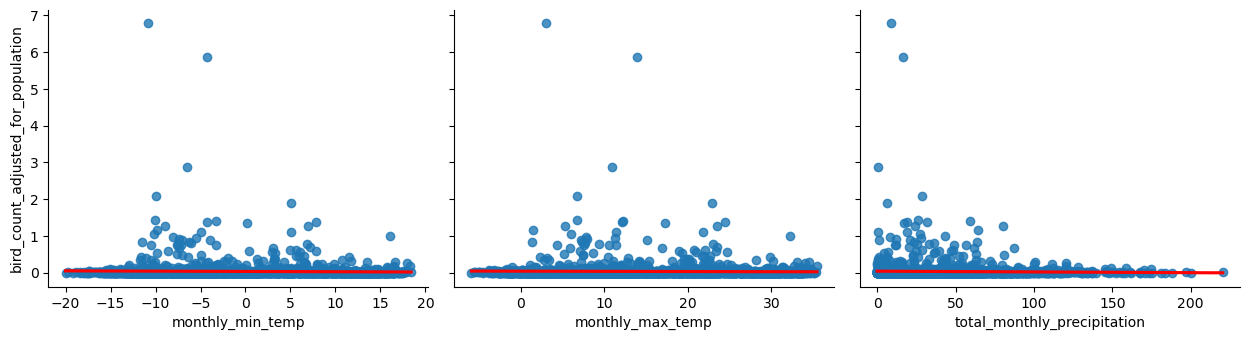

In [324]:
# # create matix of scatter plots to show relationship between total bird count per month per year and each of the weather variables (min temp, max temp, precipitation, humidity) with a regression line. Use seaborn's pairplot function to create the matrix of scatter plots. Set the kind parameter to 'reg' to include the regression line in each plot. Add labels for x and y axes and a title for the entire plot.

# Create pairplot with regression lines
p = sns.pairplot(birdsong_df_county_month, x_vars=['monthly_min_temp', 'monthly_max_temp', 'total_monthly_precipitation'], y_vars='bird_count_adjusted_for_population', kind='reg', height=3.5, aspect=1.2, plot_kws={'line_kws':{'color':'red'}})   
p.fig.subplots_adjust(top=0.5)  # Adjust the top spacing to make room for the title  
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('bird_count_weather_relationships.png', dpi=300)
plt.show()




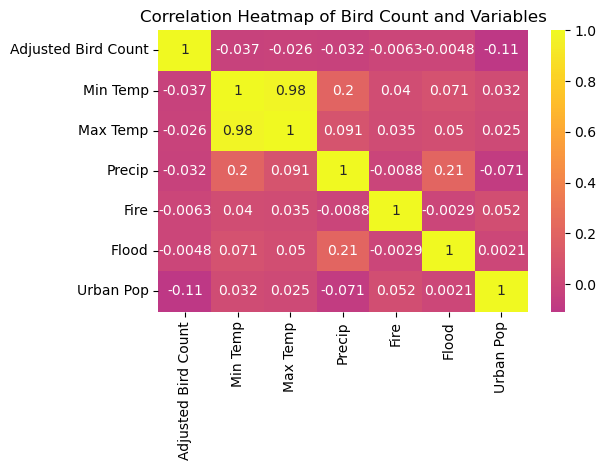

In [ ]:
# create matrix of correlation heatmaps to show relationship between bird count and each of the variables (min temp, max temp, precipitation) for each county. Use seaborn's heatmap function to create the correlation heatmaps. Set the annot parameter to True to display the correlation coefficients in each cell. Add labels for x and y axes and a title for the entire plot.

# Create a correlation matrix plot for the relevant variables and rename the columns for better readability in the heatmap
corr_matrix = birdsong_df_county_month[['bird_count_adjusted_for_population', 'monthly_min_temp', 'monthly_max_temp', 'total_monthly_precipitation' , 'is_fire', 'is_flood', 'urban_population_level']].corr()
corr_matrix.columns = ['Adjusted Bird Count', 'Min Temp', 'Max Temp', 'Precip', 'Fire', 'Flood', 'Urban Pop']
corr_matrix.index = ['Adjusted Bird Count', 'Min Temp', 'Max Temp', 'Precip', 'Fire', 'Flood', 'Urban Pop']
sns.heatmap(corr_matrix, annot=True, cmap='plasma', center=0)
plt.title('Correlation Heatmap of Bird Count and Variables')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('correlation_heatmap_bird_count_variables.png', dpi=300)
plt.show()


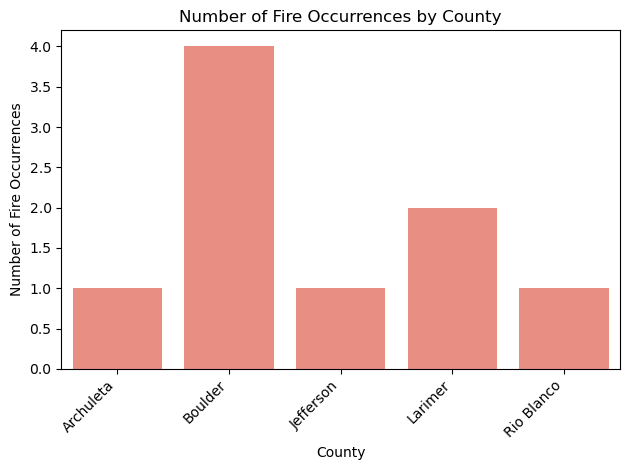

In [282]:
# count number of distinct months/years and counties with 1 in the is_fire column. Create a bar chart to show the number of distinct months/years per county with 1 in the is_fire column. Set the x-axis to 'County' and the y-axis to 'Number of Fire Occurrences'. Add labels for x and y axes and a title for the entire plot.
fire_counts = birdsong_df[birdsong_df['is_fire'] == 1].groupby('county')['date'].nunique().reset_index()
fire_counts.columns = ['county', 'fire_occurrences']
sns.barplot(x='county', y='fire_occurrences', data=fire_counts, color='salmon', errorbar=None)
plt.xlabel('County')
plt.ylabel('Number of Fire Occurrences')
plt.title('Number of Fire Occurrences by County')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('fire_occurrences_by_county.png', dpi=300)
plt.show()




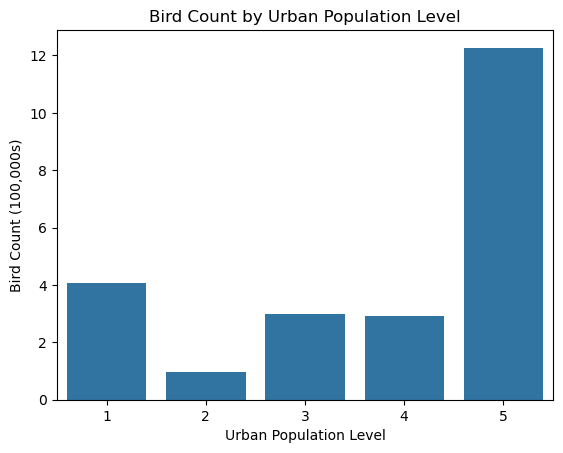

In [283]:
# Create a bar chart  to show the relationship between bird count and urban population level. Set the x-axis to 'Urban Population Level' and the y-axis to 'Bird Count'. Add labels for x and y axes and a title for the entire plot. Scale the y-axis to show bird count in hundred thousands for better visualization.

birdsong_df_grouped = birdsong_df.groupby('urban_population_level')['bird_count'].sum().reset_index()
sns.barplot(x='urban_population_level', y='bird_count', data=birdsong_df_grouped, errorbar=None, units='bird_count', estimator=lambda x: x.sum()/100000)
plt.xlabel('Urban Population Level')
plt.ylabel('Bird Count (100,000s)')
plt.title('Bird Count by Urban Population Level')
# Save the plot as a PNG file
plt.savefig('bird_count_by_urban_population_level.png', dpi=300)
plt.show()




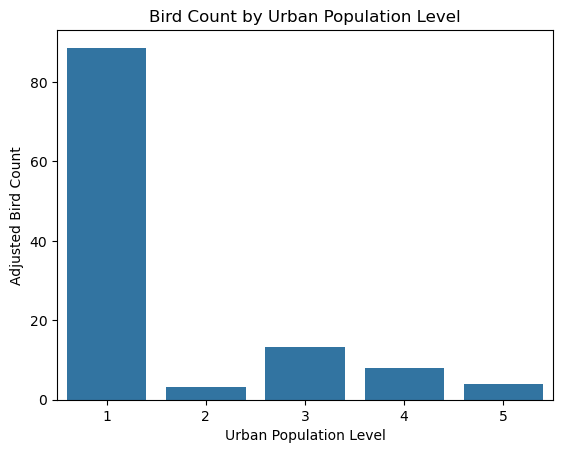

In [296]:
# Create a bar chart  to show the relationship between bird count and urban population level. Set the x-axis to 'Urban Population Level' and the y-axis to 'Bird Count'. Add labels for x and y axes and a title for the entire plot. Scale the y-axis to show bird count in hundred thousands for better visualization.

birdsong_df_grouped = birdsong_df.groupby('urban_population_level')['bird_count_adjusted_for_population'].sum().reset_index()
sns.barplot(x='urban_population_level', y='bird_count_adjusted_for_population', data=birdsong_df_grouped, errorbar=None, units='bird_count_adjusted_for_population', estimator=lambda x: x.sum())
plt.xlabel('Urban Population Level')
plt.ylabel('Adjusted Bird Count')
plt.title('Bird Count by Urban Population Level')
# Save the plot as a PNG file
plt.savefig('adjusted_bird_count_by_urban_population_level.png', dpi=300)
plt.show()




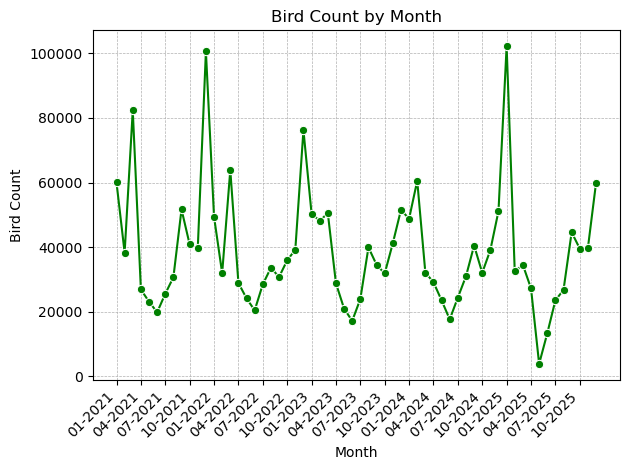

In [285]:
# create visualization to show bird counts each month from year to year to see if there is a trend in bird counts over time. Use seaborn's lineplot function to create a line graph of bird counts per year. Set the x-axis to 'Month' including the year and the y-axis to 'Bird Count'. Add labels for x and y axes and a title for the entire plot. Show dotted lines from the axis to the data points for each month and rotate x-axis labels for better readability.

# Convert date column to datetime format
birdsong_df['date'] = pd.to_datetime(birdsong_df['date'])
# Filter for the past 3 years
# three_years_ago = datetime.now() - timedelta(days=3*365)
# birdsong_df_recent = birdsong_df[birdsong_df['date'] >= three_years_ago]


birdsong_df_recent_monthly = birdsong_df.groupby('date')['bird_count'].sum().reset_index()
birdsong_df_recent_monthly['month_year'] = birdsong_df_recent_monthly['date'].dt.strftime('%m-%Y')
sns.lineplot(x='month_year', y='bird_count', data=birdsong_df_recent_monthly, marker='o', linestyle='-', color='green')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)  
plt.xlabel('Month')
plt.ylabel('Bird Count')
plt.title('Bird Count by Month')
# only show every 3rd month-year label on the x-axis for better readability
plt.xticks(ticks=range(0, len(birdsong_df_recent_monthly), 3), labels=birdsong_df_recent_monthly['month_year'][::3], rotation=45, ha='right')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('bird_count_by_month.png', dpi=300)
plt.show()




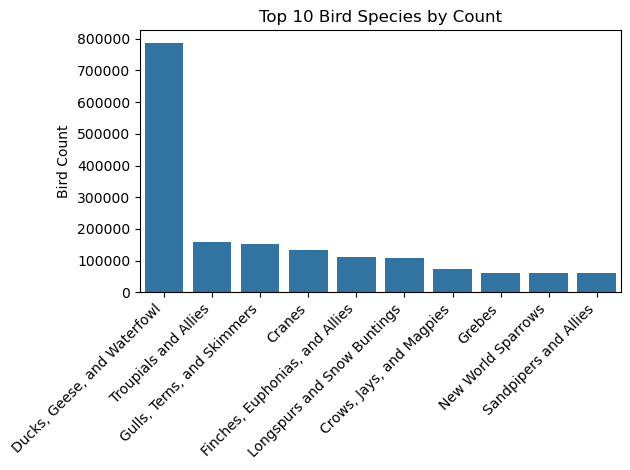

In [331]:
# display top 10 species by count in a bar chart. Set the x-axis to 'Species' and the y-axis to 'Bird Count'. Add labels for x and y axes and a title for the entire plot. Rotate x-axis labels for better readability.

top_species = birdsong_df.groupby('family')['bird_count'].sum().reset_index().sort_values(by='bird_count', ascending=False).head(10)
top10 = sns.barplot(x='family', y='bird_count', data=top_species,  errorbar=None)
top10.set(xlabel=None, ylabel='Bird Count', title='Top 10 Bird Species by Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('top_10_bird_species_by_count.png', dpi=300)
plt.show()




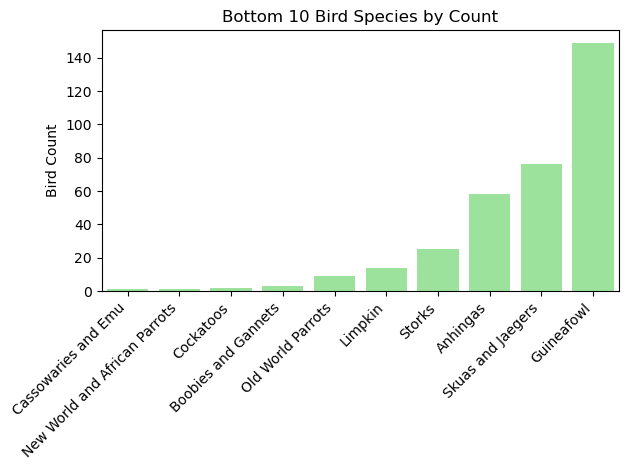

In [332]:
# display bottom 10 species by count in a bar chart. Set the x-axis to 'Species' and the y-axis to 'Bird Count'. Add labels for x and y axes and a title for the entire plot. Rotate x-axis labels for better readability.

bottom_species = birdsong_df.groupby('family')['bird_count'].sum().reset_index().sort_values(by='bird_count', ascending=True).head(10)
bottom10 = sns.barplot(x='family', y='bird_count', data=bottom_species, color='lightgreen', errorbar=None)
bottom10.set(xlabel=None, ylabel='Bird Count', title='Bottom 10 Bird Species by Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# Save the plot as a PNG file
plt.savefig('bottom_10_bird_species_by_count.png', dpi=300)
plt.show()




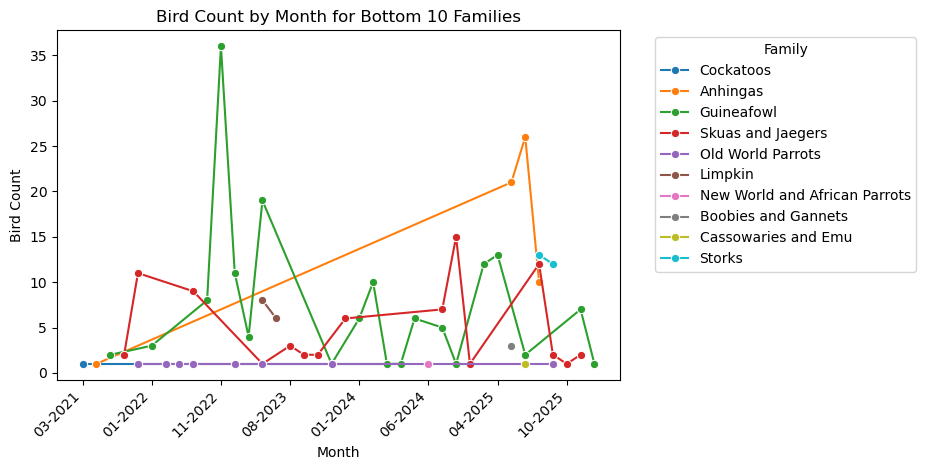

In [335]:
# Plot bird count for bottom 10 families over time by count in a line graph. Set the x-axis to 'Month' and the y-axis to 'Bird Count'. Add labels for x and y axes and a title for the entire plot. Rotate x-axis labels and only include every 3rd label for better readability. Each line should represent a different family and include a legend to differentiate between the lines.

birdsong_df_family_month_sorted_bottom = birdsong_df_family_month_sorted[birdsong_df_family_month_sorted['family'].isin(bottom_species['family'])]
# sort the dataframe by month-year and bird count in descending order to ensure the lines are in the correct order
birdsong_df_family_month_sorted_bottom = birdsong_df_family_month_sorted_bottom.sort_values(by=['month-year', 'bird_count'], ascending=[True, False])
birdsong_df_family_month_sorted_bottom = birdsong_df_family_month_sorted_bottom.sort_values(by=['month-year', 'bird_count'], ascending=[True, False])
birdsong_df_family_month_sorted_bottom['month-year'] = birdsong_df_family_month_sorted_bottom['month-year'].astype(str)
birdsong_df_family_month_sorted_bottom['month-year'] = pd.to_datetime(birdsong_df_family_month_sorted_bottom['month-year']).dt.strftime('%m-%Y')
sns.lineplot(x='month-year', y='bird_count', hue='family', data=birdsong_df_family_month_sorted_bottom, marker='o', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Bird Count')
plt.title('Bird Count by Month for Bottom 10 Families')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# update legend title to "Family"
plt.legend(title='Family', bbox_to_anchor=(1.05, 1), loc='upper left')
# only show every 3rd month-year label on the x-axis for better readability
plt.xticks(ticks=range(0, len(birdsong_df_family_month_sorted_bottom['month-year'].unique()), 5), labels=birdsong_df_family_month_sorted_bottom['month-year'].unique()[::5], rotation=45, ha='right')
# Save the plot and legend as a PNG file
plt.savefig('bird_count_by_month_for_bottom_10_families.png', dpi=300, bbox_inches='tight')
plt.show()




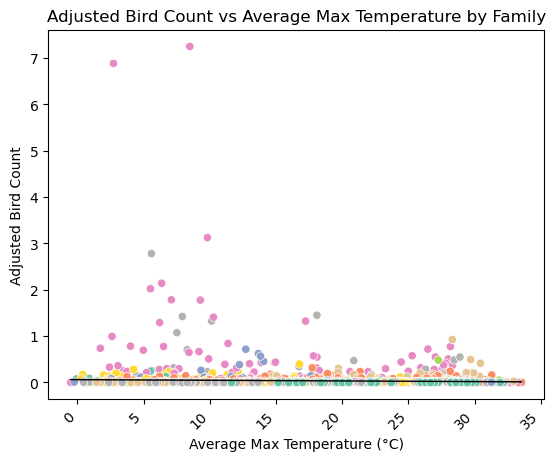

In [305]:
#plot bird_count vs avg max temp where each point is a row of the dataframe and color the points by family. Add a regression line to show the overall trend. Set the x-axis to 'Average Max Temperature' and the y-axis to 'Bird Count'. Add labels for x and y axes and a title for the entire plot. Rotate x-axis labels for better readability.

sns.scatterplot(x='monthly_max_temp', y='bird_count_adjusted_for_population', hue='family', data=birdsong_df_family_month, palette='Set2', legend=False)
sns.regplot(x='monthly_max_temp', y='bird_count_adjusted_for_population', data=birdsong_df_family_month, scatter=False, color='black', line_kws={'linewidth':1})
plt.xlabel('Average Max Temperature (°C)')          
plt.ylabel('Adjusted Bird Count')
plt.title('Adjusted Bird Count vs Average Max Temperature by Family')
plt.xticks(rotation=45, ha='right')
# Save the plot as a PNG file
plt.savefig('bird_count_vs_avg_max_temp_by_family.png', dpi=300)


# Save the plot as a PNG file
plt.savefig('bird_count_vs_avg_max_temp_by_family.png', dpi=300)
plt.show()

